# By-Region Analysis

Ranks all 23 `Order Region`s two ways — by **profit dollars** (what actually matters in a P&L review) and by **margin** (`profit / revenue`, the metric established in [`0.2_sales_corr.ipynb`](0.2_sales_corr.ipynb)) — then splits into dedicated deep-dive notebooks for the **top 3 and bottom 3 by profit $**, plus two "what do they have in common" notebooks:

| # | Notebook | Region |
|---|---|---|
| 0.5.1 | [`0.5.1_deepdive_western_europe.ipynb`](0.5.1_deepdive_western_europe.ipynb) | Western Europe (#2 profit $) |
| 0.5.2 | [`0.5.2_deepdive_central_america.ipynb`](0.5.2_deepdive_central_america.ipynb) | Central America (#1 profit $) |
| 0.5.3 | [`0.5.3_deepdive_south_america.ipynb`](0.5.3_deepdive_south_america.ipynb) | South America (#3 profit $) |
| 0.5.4 | [`0.5.4_deepdive_central_asia.ipynb`](0.5.4_deepdive_central_asia.ipynb) | Central Asia (last / #23 profit $) |
| 0.5.5 | [`0.5.5_deepdive_canada.ipynb`](0.5.5_deepdive_canada.ipynb) | Canada (2nd-to-last / #22 profit $) |
| 0.5.6 | [`0.5.6_deepdive_southern_africa.ipynb`](0.5.6_deepdive_southern_africa.ipynb) | Southern Africa (3rd-to-last / #21 profit $) |
| 0.5.7 | [`0.5.7_top3_common_ground.ipynb`](0.5.7_top3_common_ground.ipynb) | What the top 3 (by profit $) share |
| 0.5.8 | [`0.5.8_bottom3_common_ground.ipynb`](0.5.8_bottom3_common_ground.ipynb) | What the bottom 3 (by profit $) share |

Builds on [`0.4_prod_region_cross.ipynb`](0.4_prod_region_cross.ipynb). **Note:** an earlier pass at this notebook selected regions by margin %; that ranking is kept below for context because it flips the picture almost completely, but the deep dives (0.5.1–0.5.8) are now built around profit dollars, since that's the number a P&L review actually needs.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 160)

CATEGORICAL = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4', '#008300', '#4a3aa7', '#e34948']
BLUE, ORANGE = CATEGORICAL[0], CATEGORICAL[1]
POS, NEG = '#2a78d6', '#e34948'
INK = '#0b0b0b'
INK_SECONDARY = '#52514e'
INK_MUTED = '#898781'
GRID = '#e1e0d9'
SURFACE = '#fcfcfb'

plt.rcParams.update({
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE, 'axes.edgecolor': GRID,
    'axes.labelcolor': INK_SECONDARY, 'text.color': INK,
    'xtick.color': INK_MUTED, 'ytick.color': INK_MUTED,
    'axes.grid': True, 'grid.color': GRID, 'grid.linewidth': 0.8,
    'axes.spines.top': False, 'axes.spines.right': False, 'axes.spines.left': False,
    'font.size': 10,
})

def style_axis(ax, x_grid=False, y_grid=True):
    if x_grid: ax.grid(axis='x', zorder=0)
    if y_grid: ax.grid(axis='y', zorder=0)
    ax.set_axisbelow(True)
    ax.tick_params(length=0)

def usd(x, pos=None):
    if abs(x) >= 1000:
        return f"${x:,.0f}"
    return f"${x:,.1f}"

USD_FMT = mticker.FuncFormatter(usd)
DATA_DIR = '.'

In [2]:
df_full = pd.read_csv(f'{DATA_DIR}/DataCoSupplyChainDataset.csv', encoding='latin1')
df_full['order date (DateOrders)'] = pd.to_datetime(df_full['order date (DateOrders)'])
df_full['month'] = df_full['order date (DateOrders)'].dt.to_period('M')

df = df_full[df_full['order date (DateOrders)'] < '2017-10-01'].copy()  # exclude Nov-2017+ order-composition artifact (0.1)
print(f"excluded {len(df_full) - len(df):,} rows from Oct 2017 onward ({(len(df_full)-len(df))/len(df_full)*100:.1f}% of {len(df_full):,})")

TOTAL_PROFIT = df['Order Profit Per Order'].sum()
TOTAL_REVENUE = df['Order Item Total'].sum()

def region_row(region):
    sub = df[df['Order Region'] == region]
    profit = sub['Order Profit Per Order'].sum()
    revenue = sub['Order Item Total'].sum()
    return sub, profit, revenue

_all = df.groupby('Order Region').agg(revenue=('Order Item Total', 'sum'), profit=('Order Profit Per Order', 'sum'),
                                       n=('Order Id', 'size')).reset_index()
_all['margin_pct'] = _all['profit'] / _all['revenue'] * 100
_all['margin_rank'] = _all['margin_pct'].rank(ascending=False).astype(int)
_all['profit_rank'] = _all['profit'].rank(ascending=False).astype(int)
_all['pct_of_company_profit'] = _all['profit'] / TOTAL_PROFIT * 100
RANKS = _all.set_index('Order Region')

print(f"transactions: {df.shape[0]:,} rows across {df['Order Region'].nunique()} regions")
print(f"company total: revenue {usd(TOTAL_REVENUE)}, profit {usd(TOTAL_PROFIT)}")

excluded 8,557 rows from Oct 2017 onward (4.7% of 180,519)
transactions: 171,962 rows across 23 regions
company total: revenue $30,774,234, profit $3,685,985


**Data-generation artifact excluded from here on**: rows from Oct 2017 onward are dropped before revenue/profit/margin figures are computed — that window is where order composition breaks (`0.1_company_growth.ipynb` §2). `TOTAL_PROFIT`/`TOTAL_REVENUE` and every `pct_of_company_profit` figure below are computed on this excluded basis. **Exception**: the activity-window columns in §2 below (`active_start`, `active_end`, `days_active`, `months_with_orders`) intentionally use the *full*, unfiltered data — capping them at Sep 2017 would understate how long a region was really active, which is exactly what that section is measuring. See [`0.7_region_activity_gaps.ipynb`](0.7_region_activity_gaps.ipynb) for the full region-rotation investigation this uncovered.

## 1. Ranking by profit $ (primary) vs. margin % (context)

In [3]:
region_perf = df.groupby('Order Region').agg(
    revenue=('Order Item Total', 'sum'),
    profit=('Order Profit Per Order', 'sum'),
    n=('Order Id', 'size'),
).reset_index()
region_perf['margin_pct'] = region_perf['profit'] / region_perf['revenue'] * 100
region_perf['pct_of_company_profit'] = region_perf['profit'] / TOTAL_PROFIT * 100
region_perf['margin_rank'] = region_perf['margin_pct'].rank(ascending=False).astype(int)
region_perf['profit_rank'] = region_perf['profit'].rank(ascending=False).astype(int)

# activity window uses the FULL (unfiltered) data on purpose -- see note above
window = df_full.groupby('Order Region')['order date (DateOrders)'].agg(active_start='min', active_end='max')
window['days_active'] = (window['active_end'] - window['active_start']).dt.days
months_active = df_full.groupby('Order Region')['month'].nunique().rename('months_with_orders')
region_perf = region_perf.merge(window, on='Order Region').merge(months_active, on='Order Region')
market_map = df_full.drop_duplicates('Order Region').set_index('Order Region')['Market']
region_perf['market'] = region_perf['Order Region'].map(market_map)

region_perf = region_perf.sort_values('profit', ascending=False).reset_index(drop=True)

TOP3 = region_perf.head(3)['Order Region'].tolist()
BOT3 = region_perf.tail(3)['Order Region'].tolist()[::-1]  # worst first

print(f"Top 3 by profit $: {TOP3}")
print(f"Bottom 3 by profit $ (worst first): {BOT3}")
region_perf[['profit_rank', 'margin_rank', 'Order Region', 'market', 'profit', 'pct_of_company_profit', 'margin_pct', 'n', 'days_active', 'months_with_orders']].round(2)

Top 3 by profit $: ['Central America', 'Western Europe', 'South America']
Bottom 3 by profit $ (worst first): ['Central Asia', 'Canada', 'Southern Africa']


,profit_rank,margin_rank,Order Region,market,profit,pct_of_company_profit,margin_pct,n,days_active,months_with_orders
0,1,12,Central America,LATAM,616341.57,16.72,12.10,28341,894,11
1,2,13,Western Europe,Europe,551026.66,14.95,11.90,25377,894,18
2,3,7,South America,LATAM,335154.40,9.09,12.60,14935,898,11
3,4,11,Northern Europe,Europe,204373.00,5.54,12.11,9164,894,18
4,5,8,Southern Europe,Europe,201517.38,5.47,12.54,8854,894,18
5,6,22,Oceania,Pacific Asia,171872.78,4.66,11.13,8712,830,10
6,7,16,Caribbean,LATAM,171825.64,4.66,11.60,8318,892,11
7,8,14,West of USA,USCA,164940.66,4.47,11.68,7993,145,5
8,9,19,Southeast Asia,Pacific Asia,157184.66,4.26,11.35,7790,830,10
9,10,5,East of USA,USCA,156263.30,4.24,12.68,6915,145,5


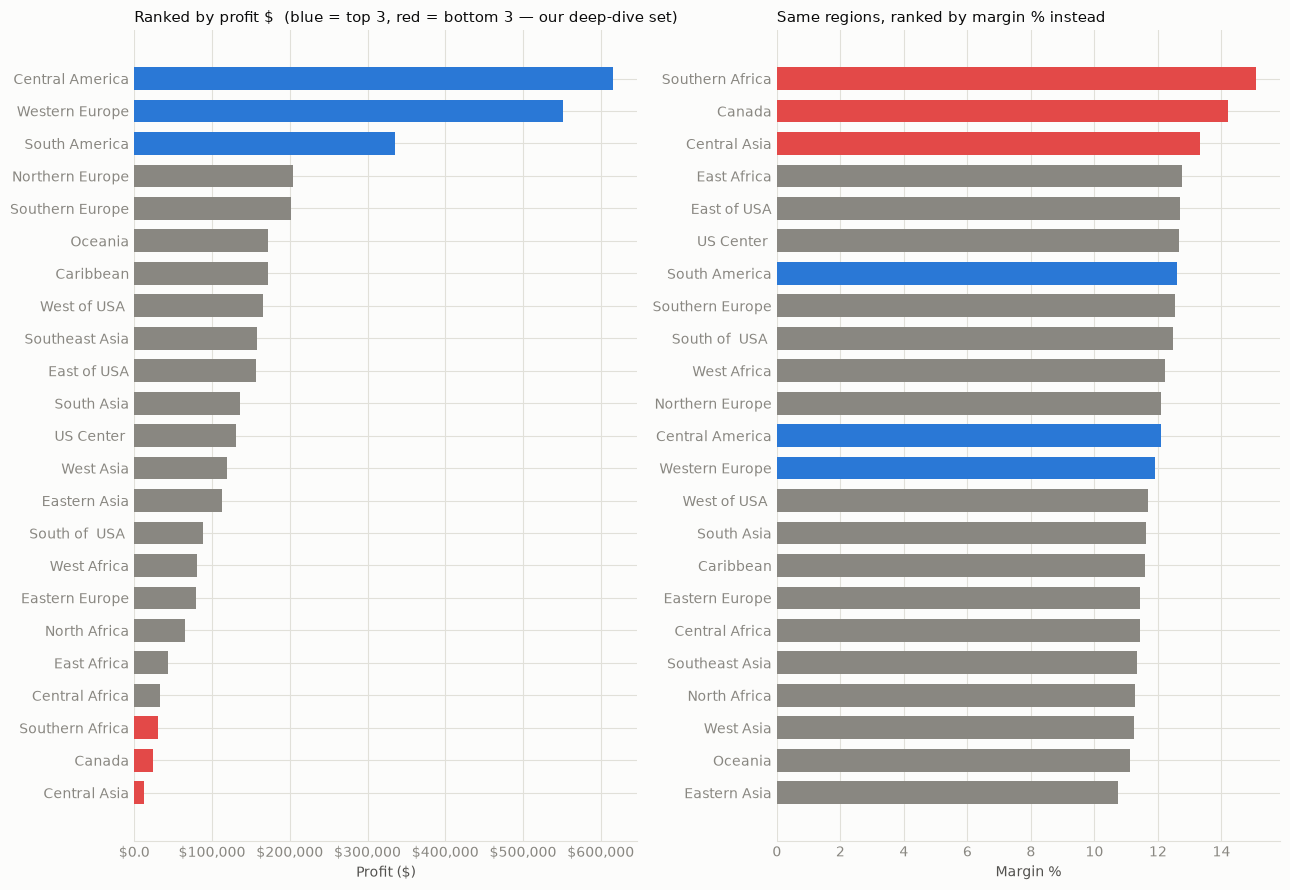

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 9), sharey=False)

order_by_profit = region_perf.sort_values('profit', ascending=False)
y = np.arange(len(order_by_profit))
colors = [BLUE if r in TOP3 else NEG if r in BOT3 else INK_MUTED for r in order_by_profit['Order Region']]
axes[0].barh(y, order_by_profit['profit'], color=colors, zorder=3, height=0.7)
axes[0].set_yticks(y); axes[0].set_yticklabels(order_by_profit['Order Region']); axes[0].invert_yaxis()
axes[0].set_xlabel('Profit ($)')
axes[0].xaxis.set_major_formatter(USD_FMT)
axes[0].set_title('Ranked by profit $  (blue = top 3, red = bottom 3 — our deep-dive set)', loc='left', color=INK, fontsize=10.5)
style_axis(axes[0], x_grid=True, y_grid=False)

order_by_margin = region_perf.sort_values('margin_pct', ascending=False)
y2 = np.arange(len(order_by_margin))
colors2 = [BLUE if r in TOP3 else NEG if r in BOT3 else INK_MUTED for r in order_by_margin['Order Region']]
axes[1].barh(y2, order_by_margin['margin_pct'], color=colors2, zorder=3, height=0.7)
axes[1].set_yticks(y2); axes[1].set_yticklabels(order_by_margin['Order Region']); axes[1].invert_yaxis()
axes[1].set_xlabel('Margin %')
axes[1].set_title('Same regions, ranked by margin % instead', loc='left', color=INK, fontsize=10.5)
style_axis(axes[1], x_grid=True, y_grid=False)

plt.tight_layout()
plt.show()

**The two rankings are almost perfectly inverted for our 6 regions of interest.** Central America, Western Europe and South America generate **$1.50M combined (40.8% of the company's $3.69M total profit)** — and rank 12th, 13th and 7th on margin, nowhere near the top. Central Asia, Canada and Southern Africa — the 3 *worst* regions by profit dollars, contributing just **$67.8K combined (1.8% of company profit)** — happen to be the 3 *best* regions by margin. Margin rewards being small; profit $ rewards being big. For a P&L conversation, profit $ is the number that matters, so that's what the deep dives below are built around.

## 2. A dataset-wide caveat: order flow is not continuous, for anyone

In [5]:
region_perf[['Order Region', 'market', 'active_start', 'active_end', 'days_active', 'months_with_orders']].sort_values('months_with_orders')

,Order Region,market,active_start,active_end,days_active,months_with_orders
11,US Center,USCA,2016-04-02 01:17:00,2016-08-25 13:52:00,145,5
7,West of USA,USCA,2016-04-01 21:05:00,2016-08-25 17:01:00,145,5
14,South of USA,USCA,2016-04-01 20:22:00,2016-08-25 15:58:00,145,5
9,East of USA,USCA,2016-04-02 04:26:00,2016-08-25 14:34:00,145,5
20,Southern Africa,Africa,2016-08-26 03:53:00,2017-01-16 21:22:00,143,6
19,Central Africa,Africa,2016-08-25 17:43:00,2017-01-15 04:44:00,142,6
18,East Africa,Africa,2016-08-27 07:12:00,2017-01-17 22:57:00,143,6
17,North Africa,Africa,2016-08-25 18:46:00,2017-01-18 07:21:00,145,6
16,Eastern Europe,Europe,2016-08-25 19:28:00,2017-01-18 16:28:00,145,6
15,West Africa,Africa,2016-08-26 01:47:00,2017-01-18 13:40:00,145,6


This isn't a small-region quirk. Even the two biggest profit contributors — Central America and South America — only have order data in **11 of the ~29 months** between their first and last order (Jan 2015 – Jun 2017): a strong run through mid-2015, then a **19-month dead zone with zero orders** (Jun 2015 – Dec 2016), then a recovery in the first half of 2017. Western Europe has **18 of ~30 months**, with its own gap pattern. The per-region notebooks (0.5.1–0.5.6) show this month by month — treat any "active window" span as an upper bound on real activity, not a continuous run.

## Takeaways — for the room

- **Rank by profit $, not margin, when the question is "where's the money."** Central America, Western Europe and South America generate $1.50M combined (40.8% of company profit); Central Asia, Canada and Southern Africa generate $67.8K combined (1.8%) despite having the best margins in the company.
- **Order flow has multi-month gaps everywhere**, including the two largest profit contributors (Central America, South America: 19 months of zero orders between Jun 2015 and Dec 2016). Any month-over-month or region-over-region comparison needs to account for this before it's presented as a trend.
- **Figures above exclude Oct 2017+** (the `0.1` order-composition artifact) — this nudges Western Europe from #1 to #2 by profit $ (Central America takes #1) versus the unfiltered read; the regions and the story otherwise don't change.
- **See 0.5.1–0.5.6** for what's driving each of the 6 regions in dollars — gains, losses, and the biggest-dollar categories in each.
- **See 0.5.7 / 0.5.8** for what the top 3 / bottom 3 by profit $ actually have in common.